In [5]:
# ============================================================
# STEP 1: DEFINE THE PROBLEM
# ============================================================
# Task:
# Classify brain MRI images into 4 classes:
# glioma, meningioma, notumor, pituitary
#
# ML Type:
# Supervised Multi-class Image Classification
#
# Performance Metrics:
# Accuracy, Precision, Recall, F1-score, Confusion Matrix
#
# Algorithm/Method:
# Transfer Learning using VGG16
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import load_img, img_to_array

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ============================================================
# STEP 2: COLLECT AND PREPARE DATA
# ============================================================

DRIVE_DATASET_DIR = "/content/drive/MyDrive/bt_detection/archive"
LOCAL_DATASET_DIR = "/content/brain_tumor_archive"

DRIVE_TRAIN_DIR = os.path.join(DRIVE_DATASET_DIR, "Training")
DRIVE_TEST_DIR = os.path.join(DRIVE_DATASET_DIR, "Testing")

if not os.path.exists(DRIVE_TRAIN_DIR):
    raise FileNotFoundError(f"Training folder not found: {DRIVE_TRAIN_DIR}")

if not os.path.exists(DRIVE_TEST_DIR):
    raise FileNotFoundError(f"Testing folder not found: {DRIVE_TEST_DIR}")

print("Drive dataset found.")
print("Drive Training folder:", DRIVE_TRAIN_DIR)
print("Drive Testing folder :", DRIVE_TEST_DIR)

# Copy dataset to local Colab storage for faster image loading.
# This is much faster than reading thousands of images directly from Google Drive during training.

if os.path.exists(LOCAL_DATASET_DIR):
    print("Removing old local dataset copy...")
    shutil.rmtree(LOCAL_DATASET_DIR)

print("Copying dataset from Google Drive to local Colab storage...")
shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
print("Dataset copied successfully.")

DATASET_DIR = LOCAL_DATASET_DIR
TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR = os.path.join(DATASET_DIR, "Testing")

print("Local dataset folder :", DATASET_DIR)
print("Local Training folder:", TRAIN_DIR)
print("Local Testing folder :", TEST_DIR)

Drive dataset found.
Drive Training folder: /content/drive/MyDrive/bt_detection/archive/Training
Drive Testing folder : /content/drive/MyDrive/bt_detection/archive/Testing
Copying dataset from Google Drive to local Colab storage...
Dataset copied successfully.
Local dataset folder : /content/brain_tumor_archive
Local Training folder: /content/brain_tumor_archive/Training
Local Testing folder : /content/brain_tumor_archive/Testing


In [7]:
# ============================================================
# STEP 2: DATA PREPARATION
# Create a dataframe containing image paths and labels
# ============================================================

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def build_dataframe(data_dir):
    filepaths = []
    labels = []

    data_dir = Path(data_dir)

    for class_dir in sorted(data_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        label = class_dir.name

        for file_path in sorted(class_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
                filepaths.append(str(file_path))
                labels.append(label)

    df = pd.DataFrame({
        "filepaths": filepaths,
        "labels": labels
    })

    return df


full_train_df = build_dataframe(TRAIN_DIR)
test_df = build_dataframe(TEST_DIR)

print("Full training images:", len(full_train_df))
print("Official test images :", len(test_df))

print("\nTraining class counts:")
print(full_train_df["labels"].value_counts().sort_index())

print("\nTesting class counts:")
print(test_df["labels"].value_counts().sort_index())

assert len(full_train_df) > 0, "No training images found."
assert len(test_df) > 0, "No testing images found."

assert set(full_train_df["labels"].unique()) == set(test_df["labels"].unique()), \
    "Training and testing classes do not match."

class_names = sorted(full_train_df["labels"].unique())

print("\nClasses:", class_names)

Full training images: 5601
Official test images : 1604

Training class counts:
labels
glioma        1400
meningioma    1401
notumor       1400
pituitary     1400
Name: count, dtype: int64

Testing class counts:
labels
glioma        400
meningioma    404
notumor       400
pituitary     400
Name: count, dtype: int64

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
# ============================================================
# STEP 2: DATA CLEANING / SANITY CHECK
# ============================================================
# Full image validation is slow.
# Instead, we check whether file paths exist and skip expensive image-by-image validation.

missing_train = full_train_df[~full_train_df["filepaths"].apply(os.path.exists)]
missing_test = test_df[~test_df["filepaths"].apply(os.path.exists)]

print("Missing training files:", len(missing_train))
print("Missing testing files :", len(missing_test))

if len(missing_train) > 0:
    display(missing_train)

if len(missing_test) > 0:
    display(missing_test)

full_train_df = full_train_df[full_train_df["filepaths"].apply(os.path.exists)].reset_index(drop=True)
test_df = test_df[test_df["filepaths"].apply(os.path.exists)].reset_index(drop=True)

print("Final training dataframe size:", len(full_train_df))
print("Final testing dataframe size :", len(test_df))

Missing training files: 0
Missing testing files : 0
Final training dataframe size: 5601
Final testing dataframe size : 1604


In [9]:
# ============================================================
# STEP 2: DATA PREPARATION
# Correct split:
# Training folder -> train + validation
# Testing folder  -> final test only
# ============================================================

train_df, valid_df = train_test_split(
    full_train_df,
    test_size=0.20,
    stratify=full_train_df["labels"],
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train images     :", len(train_df))
print("Validation images:", len(valid_df))
print("Test images      :", len(test_df))

print("\nTrain counts:")
print(train_df["labels"].value_counts().sort_index())

print("\nValidation counts:")
print(valid_df["labels"].value_counts().sort_index())

print("\nTest counts:")
print(test_df["labels"].value_counts().sort_index())

Train images     : 4480
Validation images: 1121
Test images      : 1604

Train counts:
labels
glioma        1120
meningioma    1120
notumor       1120
pituitary     1120
Name: count, dtype: int64

Validation counts:
labels
glioma        280
meningioma    281
notumor       280
pituitary     280
Name: count, dtype: int64

Test counts:
labels
glioma        400
meningioma    404
notumor       400
pituitary     400
Name: count, dtype: int64


            train  validation  test
labels                             
glioma       1120         280   400
meningioma   1120         281   404
notumor      1120         280   400
pituitary    1120         280   400


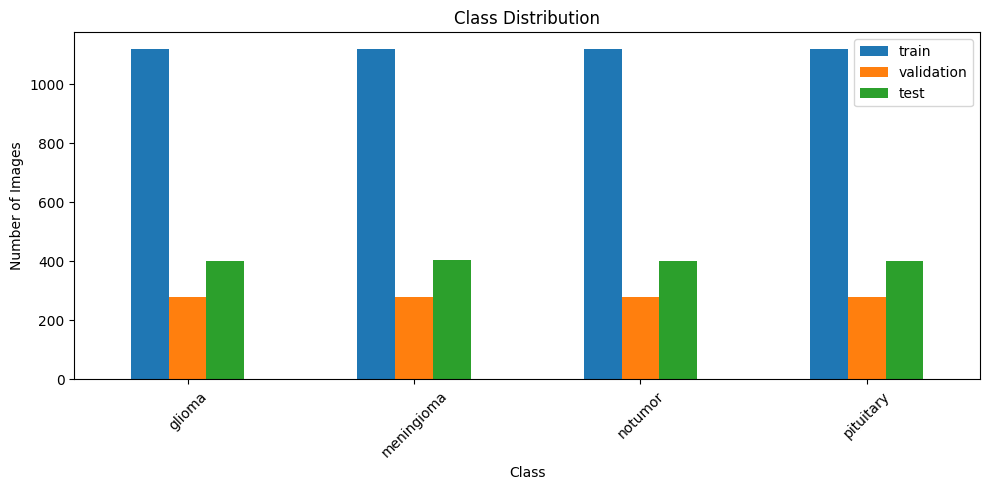

In [10]:
# ============================================================
# STEP 3: EXPLORE AND UNDERSTAND DATA
# ============================================================

class_counts = pd.DataFrame({
    "train": train_df["labels"].value_counts().sort_index(),
    "validation": valid_df["labels"].value_counts().sort_index(),
    "test": test_df["labels"].value_counts().sort_index()
})

print(class_counts)

class_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12431/3340579137.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(2, random_state=SEED))


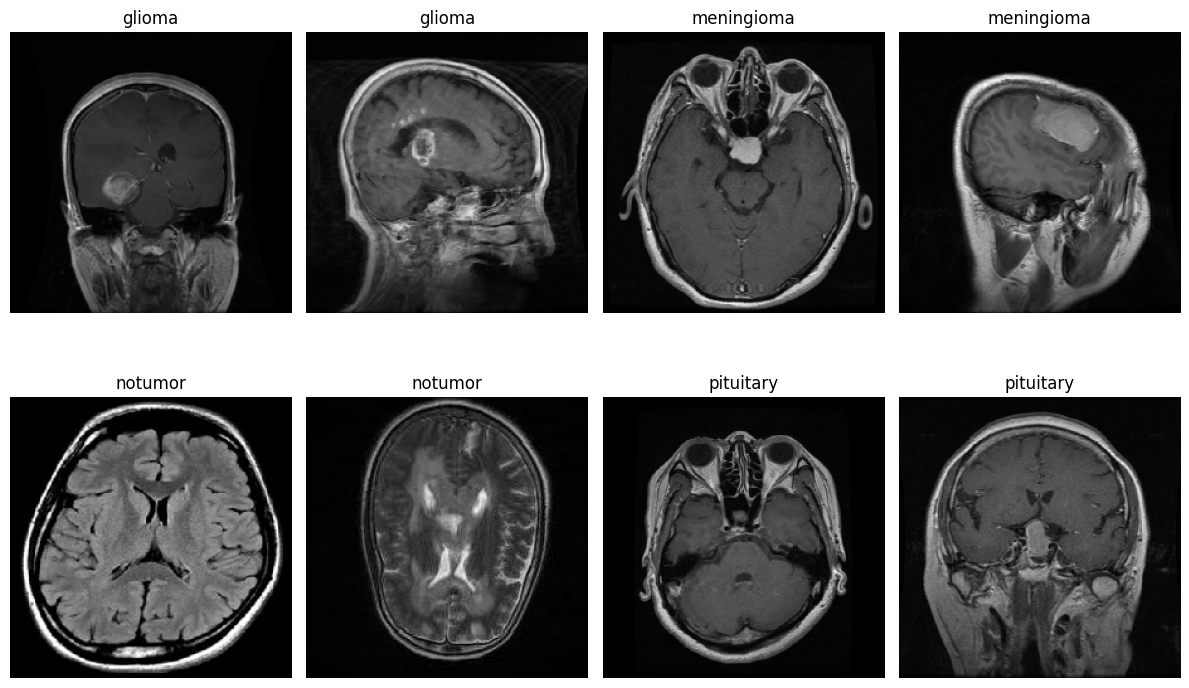

In [11]:
# ============================================================
# STEP 3: DATA VISUALIZATION
# ============================================================

sample_df = (
    train_df
    .groupby("labels", group_keys=False)
    .apply(lambda x: x.sample(2, random_state=SEED))
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 8))

for i, row in enumerate(sample_df.itertuples(), start=1):
    img = load_img(row.filepaths, target_size=(224, 224))

    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(row.labels)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# STEP 4: FEATURE ENGINEERING
# ============================================================
# For image classification, feature engineering is handled through:
# 1. Image resizing
# 2. VGG16 preprocessing
# 3. Data augmentation
# 4. Transfer learning feature extraction
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

preprocess_input = keras.applications.vgg16.preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_gen = valid_test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_count = len(class_indices)

print("Class indices:", class_indices)
print("Number of classes:", class_count)

Found 4480 validated image filenames belonging to 4 classes.
Found 1121 validated image filenames belonging to 4 classes.
Found 1604 validated image filenames belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Number of classes: 4


In [13]:
# ============================================================
# STEP 4: HANDLE CLASS BALANCE
# ============================================================
# Your dataset appears balanced, but this keeps the code safe
# if extra files caused imbalance.
# ============================================================

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_names),
    y=train_df["labels"].values
)

class_weight_dict = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for i, weight in class_weight_dict.items():
    print(idx_to_class[i], ":", weight)

Class weights:
glioma : 1.0
meningioma : 1.0
notumor : 1.0
pituitary : 1.0


In [14]:
# ============================================================
# STEP 5: SELECT OR DEVELOP ML METHOD
# ============================================================
# Method:
# VGG16 Transfer Learning
# ============================================================

IMG_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)

base_model = keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SHAPE
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SHAPE)

x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.40)(x)

x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.30)(x)

outputs = keras.layers.Dense(class_count, activation="softmax")(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="vgg16_brain_tumor_classifier"
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16_brain_tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,116 (56.65 MB)

 Trainable params: 133,892 (523.02 KB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [15]:
# ============================================================
# STEP 6: TRAINING SETUP
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/bt_detection/fixed_model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FROZEN_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_vgg16_frozen.keras")
FINETUNED_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_vgg16_finetuned.keras")
FINAL_MODEL_PATH = os.path.join(OUTPUT_DIR, "brain_tumor_vgg16_best.keras")
H5_MODEL_PATH = os.path.join(OUTPUT_DIR, "brain_tumor_vgg16_best.h5")
CLASS_INDICES_PATH = os.path.join(OUTPUT_DIR, "class_indices.json")
TRAIN_HISTORY_PATH = os.path.join(OUTPUT_DIR, "training_history.json")

with open(CLASS_INDICES_PATH, "w") as f:
    json.dump(class_indices, f, indent=4)

callbacks_frozen = [
    ModelCheckpoint(
        FROZEN_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Output folder:", OUTPUT_DIR)
print("Class labels saved at:", CLASS_INDICES_PATH)

Output folder: /content/drive/MyDrive/bt_detection/fixed_model_output
Class labels saved at: /content/drive/MyDrive/bt_detection/fixed_model_output/class_indices.json


In [16]:
# ============================================================
# STEP 6: TRAIN THE MODEL
# Phase 1:
# Train only the custom classification head
# ============================================================

EPOCHS_FROZEN = 25

history_frozen = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks_frozen,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5671 - loss: 1.1805
Epoch 1: val_accuracy improved from None to 0.84389, saving model to /content/drive/MyDrive/bt_detection/fixed_model_output/best_vgg16_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/bt_detection/fixed_model_output/best_vgg16_frozen.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 90s 276ms/step - accuracy: 0.6810 - loss: 0.8830 - val_accuracy: 0.8439 - val_loss: 0.4440 - learning_rate: 3.0000e-04
Epoch 2/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7785 - loss: 0.6019
Epoch 2: val_accuracy improved from 0.84389 to 0.86887, saving model to /content/drive/MyDrive/bt_detection/fixed_model_output/best_vgg16_frozen.keras

Epoch 2: finished saving model to /content/drive/MyDrive/bt_detection/fixed_model_output/best_vgg16_frozen.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 75s 267ms/step - accuracy: 0.7871 - loss: 0.5918 - val_accuracy: 0.8689 - val_loss: 0.3504 - learning_rate: 3.0000e-04
E

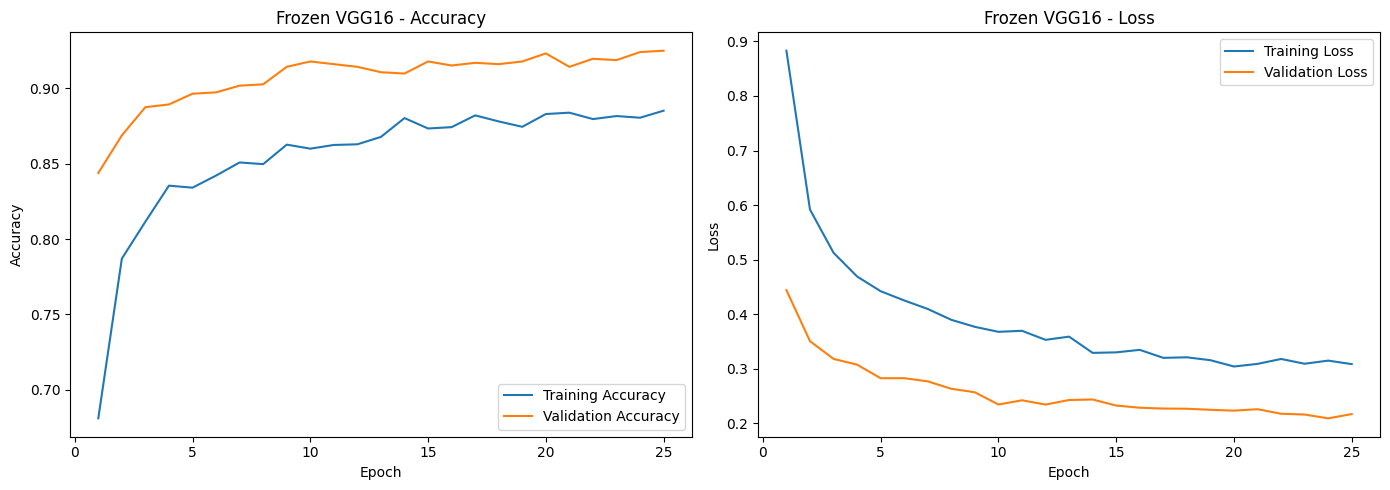

In [17]:
# ============================================================
# STEP 7: EVALUATE TRAINING BEHAVIOR
# ============================================================

def plot_history(history, title="Training History"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])

    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(history_frozen, title="Frozen VGG16")

In [18]:
# ============================================================
# STEP 8: TUNE AND IMPROVE MODEL
# Fine-tune only block5 of VGG16
# ============================================================

model = keras.models.load_model(FROZEN_MODEL_PATH)

vgg16_base = None

for layer in model.layers:
    if "vgg16" in layer.name.lower():
        vgg16_base = layer
        break

if vgg16_base is None:
    raise ValueError("VGG16 base model not found.")

vgg16_base.trainable = True

for layer in vgg16_base.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_finetune = [
    ModelCheckpoint(
        FINETUNED_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

model.summary()

Model: "vgg16_brain_tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,116 (56.65 MB)

 Trainable params: 7,213,316 (27.52 MB)

 Non-trainable params: 7,636,800 (29.13 MB)

In [19]:
# ============================================================
# STEP 8: MODEL IMPROVEMENT
# Phase 2:
# Fine-tune the last convolutional block
# ============================================================

EPOCHS_FINETUNE = 15

history_finetune = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks_finetune,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8824 - loss: 0.2895
Epoch 1: val_accuracy improved from None to 0.92774, saving model to /content/drive/MyDrive/bt_detection/fixed_model_output/best_vgg16_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/bt_detection/fixed_model_output/best_vgg16_finetuned.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 82s 268ms/step - accuracy: 0.8891 - loss: 0.2848 - val_accuracy: 0.9277 - val_loss: 0.2069 - learning_rate: 1.0000e-05
Epoch 2/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9116 - loss: 0.2253
Epoch 2: val_accuracy did not improve from 0.92774
280/280 ━━━━━━━━━━━━━━━━━━━━ 73s 260ms/step - accuracy: 0.9167 - loss: 0.2237 - val_accuracy: 0.9242 - val_loss: 0.1861 - learning_rate: 1.0000e-05
Epoch 3/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9274 - loss: 0.1842
Epoch 3: val_accuracy improved from 0.92774 to 0.95272, saving model to /content/drive/MyDrive/bt_detection/fixed_model_o

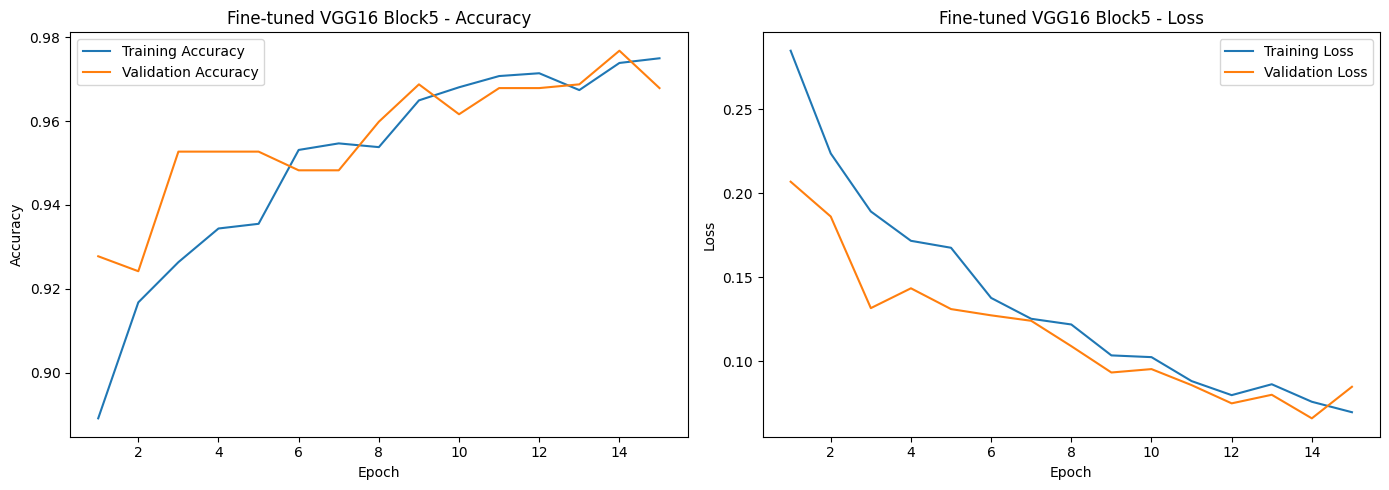

In [20]:
# ============================================================
# STEP 7 + STEP 8:
# Evaluate fine-tuning behavior
# ============================================================

plot_history(history_finetune, title="Fine-tuned VGG16 Block5")

In [21]:
# ============================================================
# STEP 7: VALIDATION EVALUATION
# Select the best model based on validation accuracy
# ============================================================

valid_gen.reset()

frozen_model = keras.models.load_model(FROZEN_MODEL_PATH)
frozen_val_loss, frozen_val_acc = frozen_model.evaluate(valid_gen, verbose=1)

if os.path.exists(FINETUNED_MODEL_PATH):
    valid_gen.reset()
    finetuned_model = keras.models.load_model(FINETUNED_MODEL_PATH)
    finetuned_val_loss, finetuned_val_acc = finetuned_model.evaluate(valid_gen, verbose=1)
else:
    finetuned_model = None
    finetuned_val_loss = np.inf
    finetuned_val_acc = 0.0

print("Frozen validation loss         :", frozen_val_loss)
print("Frozen validation accuracy     :", frozen_val_acc)

print("Fine-tuned validation loss     :", finetuned_val_loss)
print("Fine-tuned validation accuracy :", finetuned_val_acc)

if finetuned_val_acc >= frozen_val_acc:
    best_model = finetuned_model
    selected_model_name = "fine-tuned VGG16"
else:
    best_model = frozen_model
    selected_model_name = "frozen VGG16"

best_model.save(FINAL_MODEL_PATH)

print("\nSelected model:", selected_model_name)
print("Final best model saved at:", FINAL_MODEL_PATH)

71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.9251 - loss: 0.2167
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.9768 - loss: 0.0661
Frozen validation loss         : 0.21666018664836884
Frozen validation accuracy     : 0.9250668883323669
Fine-tuned validation loss     : 0.06608723849058151
Fine-tuned validation accuracy : 0.9768064022064209

Selected model: fine-tuned VGG16
Final best model saved at: /content/drive/MyDrive/bt_detection/fixed_model_output/brain_tumor_vgg16_best.keras


In [22]:
# ============================================================
# STEP 7: FINAL MODEL TESTING
# Important:
# Test set is used only here, after model selection.
# ============================================================

test_gen.reset()

best_model = keras.models.load_model(FINAL_MODEL_PATH)

test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)

print("Final Test Loss    :", test_loss)
print("Final Test Accuracy:", test_acc)

101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - accuracy: 0.9483 - loss: 0.3028
Final Test Loss    : 0.3027662932872772
Final Test Accuracy: 0.9482543468475342


In [23]:
# ============================================================
# STEP 7: DETAILED PERFORMANCE EVALUATION
# ============================================================

test_gen.reset()

pred_probs = best_model.predict(test_gen, verbose=1)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

class_names_ordered = [idx_to_class[i] for i in range(len(idx_to_class))]

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names_ordered,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names_ordered
))

display(report_df)

101/101 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step
              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.88      0.98      0.93       404
     notumor       0.95      1.00      0.97       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.95      1604
   macro avg       0.95      0.95      0.95      1604
weighted avg       0.95      0.95      0.95      1604



,precision,recall,f1-score,support
glioma,0.993884,0.812500,0.894085,400.000000
meningioma,0.880266,0.982673,0.928655,404.000000
notumor,0.945626,1.000000,0.972053,400.000000
pituitary,0.990074,0.997500,0.993773,400.000000
accuracy,0.948254,0.948254,0.948254,0.948254
macro avg,0.952463,0.948168,0.947142,1604.000000
weighted avg,0.952283,0.948254,0.947096,1604.000000


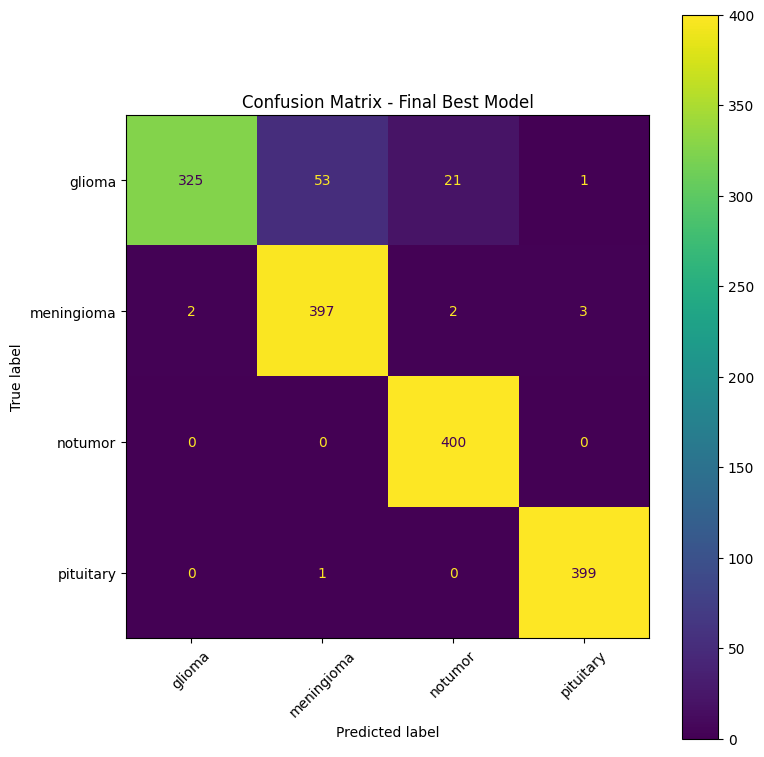

In [24]:
# ============================================================
# STEP 7: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_ordered
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Final Best Model")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# STEP 8: SAVE FINAL IMPROVED MODEL
# ============================================================

best_model.save(H5_MODEL_PATH)

metrics_summary = {
    "selected_model": selected_model_name,
    "frozen_validation_loss": float(frozen_val_loss),
    "frozen_validation_accuracy": float(frozen_val_acc),
    "finetuned_validation_loss": float(finetuned_val_loss),
    "finetuned_validation_accuracy": float(finetuned_val_acc),
    "final_test_loss": float(test_loss),
    "final_test_accuracy": float(test_acc),
    "class_indices": class_indices
}

METRICS_PATH = os.path.join(OUTPUT_DIR, "metrics_summary.json")

with open(METRICS_PATH, "w") as f:
    json.dump(metrics_summary, f, indent=4)

print("Final Keras model:", FINAL_MODEL_PATH)
print("Final H5 model   :", H5_MODEL_PATH)
print("Class labels JSON:", CLASS_INDICES_PATH)
print("Metrics JSON     :", METRICS_PATH)

Final Keras model: /content/drive/MyDrive/bt_detection/fixed_model_output/brain_tumor_vgg16_best.keras
Final H5 model   : /content/drive/MyDrive/bt_detection/fixed_model_output/brain_tumor_vgg16_best.h5
Class labels JSON: /content/drive/MyDrive/bt_detection/fixed_model_output/class_indices.json
Metrics JSON     : /content/drive/MyDrive/bt_detection/fixed_model_output/metrics_summary.json


In [26]:
# ============================================================
# STEP 8: SAVE TRAINING HISTORY
# ============================================================

training_history = {
    "frozen": history_frozen.history,
    "finetuned": history_finetune.history
}

with open(TRAIN_HISTORY_PATH, "w") as f:
    json.dump(training_history, f, indent=4)

print("Training history saved at:", TRAIN_HISTORY_PATH)

Training history saved at: /content/drive/MyDrive/bt_detection/fixed_model_output/training_history.json


In [27]:
# ============================================================
# STEP 9: MAKE PREDICTIONS / CLASSIFICATIONS
# ============================================================

def predict_brain_tumor(
    image_path,
    model_path=FINAL_MODEL_PATH,
    class_indices_path=CLASS_INDICES_PATH
):
    model = keras.models.load_model(model_path)

    with open(class_indices_path, "r") as f:
        class_indices = json.load(f)

    idx_to_class = {int(v): k for k, v in class_indices.items()}

    img = load_img(image_path, target_size=IMG_SIZE)
    arr = img_to_array(img)

    arr = np.expand_dims(arr, axis=0)
    arr = keras.applications.vgg16.preprocess_input(arr)

    probs = model.predict(arr, verbose=0)[0]

    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class[pred_idx]
    confidence = float(probs[pred_idx])

    result = {
        "predicted_class": pred_label,
        "confidence": confidence,
        "all_probabilities": {
            idx_to_class[i]: float(probs[i])
            for i in range(len(probs))
        }
    }

    return result

Image path: /content/brain_tumor_archive/Testing/glioma/Te-gl_1.jpg
True label: glioma
Prediction result:
{'predicted_class': 'glioma', 'confidence': 0.5728602409362793, 'all_probabilities': {'glioma': 0.5728602409362793, 'meningioma': 0.08994666486978531, 'notumor': 0.33566814661026, 'pituitary': 0.0015249596908688545}}


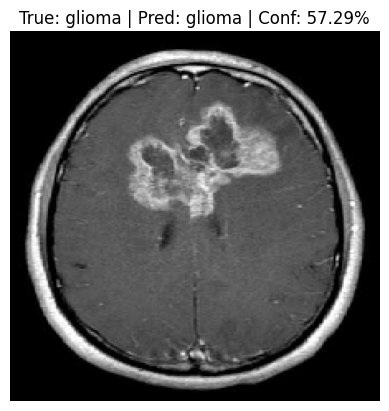

In [28]:
# ============================================================
# STEP 9: TEST SINGLE PREDICTION
# ============================================================

example_image = test_df.iloc[0]["filepaths"]
true_label = test_df.iloc[0]["labels"]

result = predict_brain_tumor(example_image)

print("Image path:", example_image)
print("True label:", true_label)
print("Prediction result:")
print(result)

img = load_img(example_image, target_size=IMG_SIZE)

plt.imshow(img)
plt.title(
    f"True: {true_label} | "
    f"Pred: {result['predicted_class']} | "
    f"Conf: {result['confidence']:.2%}"
)
plt.axis("off")
plt.show()

Prediction result:
{'predicted_class': 'notumor', 'confidence': 0.9999990463256836, 'all_probabilities': {'glioma': 3.772475167806988e-07, 'meningioma': 1.7109842076479254e-07, 'notumor': 0.9999990463256836, 'pituitary': 4.5186502006799856e-07}}


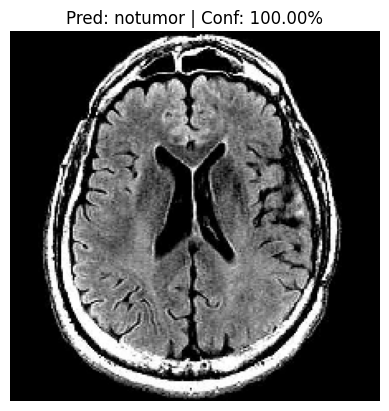

In [31]:
# ============================================================
# STEP 9: PREDICT CUSTOM IMAGE
# ============================================================
# Upload your image to Colab, then set the path below.

CUSTOM_IMAGE_PATH = "/content/drive/MyDrive/bt_detection/archive/Testing/meningioma/Te-aug-me_24.jpg"

if os.path.exists(CUSTOM_IMAGE_PATH):
    result = predict_brain_tumor(CUSTOM_IMAGE_PATH)

    print("Prediction result:")
    print(result)

    img = load_img(CUSTOM_IMAGE_PATH, target_size=IMG_SIZE)

    plt.imshow(img)
    plt.title(
        f"Pred: {result['predicted_class']} | "
        f"Conf: {result['confidence']:.2%}"
    )
    plt.axis("off")
    plt.show()
else:
    print("No custom image found at:", CUSTOM_IMAGE_PATH)
    print("Upload an image and update CUSTOM_IMAGE_PATH.")

In [30]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("Machine Learning Pipeline Completed")
print("-----------------------------------")
print("Task:")
print("Brain tumor MRI classification")

print("\nAlgorithm/Method:")
print("VGG16 Transfer Learning + Fine-tuning")

print("\nClasses:")
print(class_names_ordered)

print("\nSelected Model:")
print(selected_model_name)

print("\nFinal Test Accuracy:")
print(test_acc)

print("\nSaved Files:")
print("Best .keras model :", FINAL_MODEL_PATH)
print("Best .h5 model    :", H5_MODEL_PATH)
print("Class labels      :", CLASS_INDICES_PATH)
print("Metrics summary   :", METRICS_PATH)
print("Training history  :", TRAIN_HISTORY_PATH)

Machine Learning Pipeline Completed
-----------------------------------
Task:
Brain tumor MRI classification

Algorithm/Method:
VGG16 Transfer Learning + Fine-tuning

Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Selected Model:
fine-tuned VGG16

Final Test Accuracy:
0.9482543468475342

Saved Files:
Best .keras model : /content/drive/MyDrive/bt_detection/fixed_model_output/brain_tumor_vgg16_best.keras
Best .h5 model    : /content/drive/MyDrive/bt_detection/fixed_model_output/brain_tumor_vgg16_best.h5
Class labels      : /content/drive/MyDrive/bt_detection/fixed_model_output/class_indices.json
Metrics summary   : /content/drive/MyDrive/bt_detection/fixed_model_output/metrics_summary.json
Training history  : /content/drive/MyDrive/bt_detection/fixed_model_output/training_history.json
